## KNN

In [229]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [230]:
# Cargar datos procesados (usando joblib)
data = joblib.load('../data/processed_data.pkl')
print (data.keys())

dict_keys(['X_train', 'X_test', 'y_train', 'y_test', 'feature_names'])


X_train: (3576, 14)
y_train: (3576,)
X_test: (1533, 14)
y_test: (1533,)


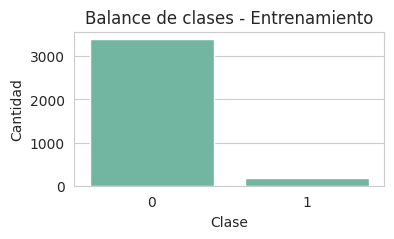

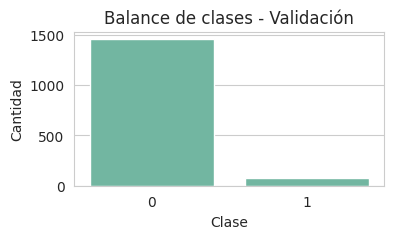

In [240]:



X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

# Balance de clases
def plot_class_balance(y, title):
    plt.figure(figsize=(4,2))
    sns.countplot(x=y)
    plt.title(title)
    plt.xlabel('Clase')
    plt.ylabel('Cantidad')
    plt.show()

plot_class_balance(y_train, 'Balance de clases - Entrenamiento')
plot_class_balance(y_test, 'Balance de clases - Validación')

In [232]:
# ============================================================
# KNN — detectar Stroke=1
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve,
                             recall_score)

# ---



Mejor K (por Recall Stroke=1): 1 (recall: 0.0933)


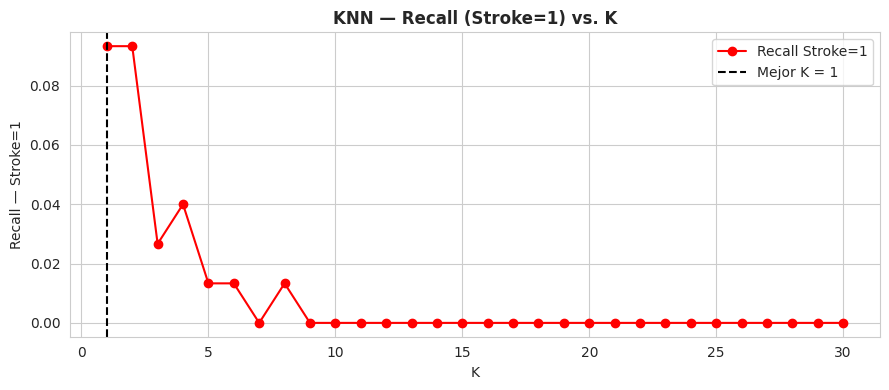

In [233]:

# ---
# Busqueda del mejor K buscando Recall de Stroke=1
k_range = range(1, 31)
recall_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights="distance", metric="minkowski")
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    recall_scores.append(recall_score(y_test, y_pred_k))

best_k = recall_scores.index(max(recall_scores)) + 1
print(f"Mejor K (por Recall Stroke=1): {best_k} (recall: {max(recall_scores):.4f})")


plt.figure(figsize=(9, 4))
plt.plot(k_range, recall_scores, marker="o", color="red", label="Recall Stroke=1")
plt.axvline(best_k, linestyle="--", color="black", label=f"Mejor K = {best_k}")
plt.title("KNN — Recall (Stroke=1) vs. K", fontweight="bold")
plt.xlabel("K"); plt.ylabel("Recall — Stroke=1")
plt.legend(); plt.tight_layout(); plt.show()


In [234]:
# ---
# Entrenar con el mejor K + umbral ajustado
knn_best = KNeighborsClassifier(n_neighbors=best_k, weights="distance", metric="minkowski")
knn_best.fit(X_train, y_train)
y_proba = knn_best.predict_proba(X_test)[:, 1]

# Bajar el umbral de decisión de 0.5 a 0.3 para capturar más Stroke=1
THRESHOLD = 0.3
y_pred = (y_proba >= THRESHOLD).astype(int)

print("\n=============================")
print(f"KNN (umbral={THRESHOLD})")
print("=============================")
print(classification_report(y_test, y_pred, target_names=["No Stroke", "Stroke"]))



KNN (umbral=0.3)
              precision    recall  f1-score   support

   No Stroke       0.95      0.95      0.95      1458
      Stroke       0.09      0.09      0.09        75

    accuracy                           0.91      1533
   macro avg       0.52      0.52      0.52      1533
weighted avg       0.91      0.91      0.91      1533



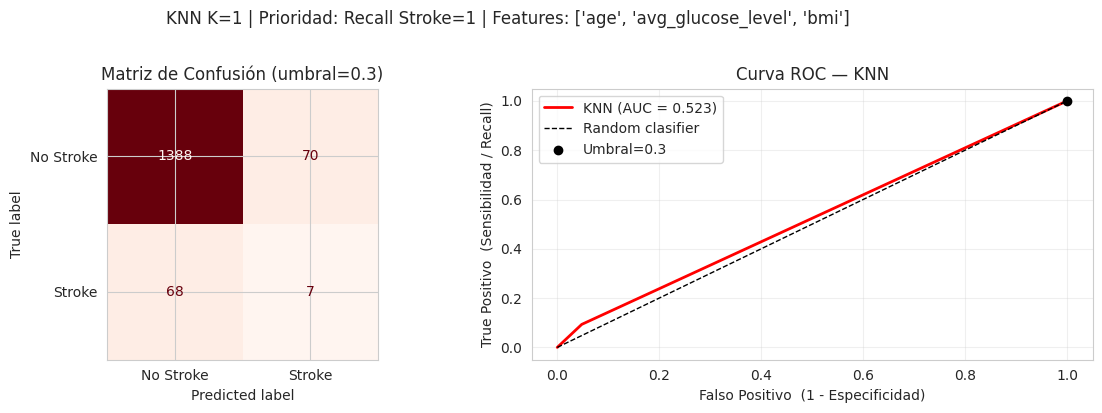

In [235]:
# Matriz de confusion - Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Stroke", "Stroke"])
disp.plot(ax=axes[0], colorbar=False, cmap="Reds")
axes[0].set_title(f"Matriz de Confusión (umbral={THRESHOLD})")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

axes[1].plot(fpr, tpr, color="red", lw=2, label=f"KNN (AUC = {auc_score:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random clasifier")

# umbral
idx = np.argmin(np.abs(thresholds - THRESHOLD))
axes[1].scatter(fpr[idx], tpr[idx], color="black", zorder=5,label=f"Umbral={THRESHOLD}")
axes[1].set_xlabel("Falso Positivo  (1 - Especificidad)")
axes[1].set_ylabel("True Positivo  (Sensibilidad / Recall)")
axes[1].set_title("Curva ROC — KNN")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f"KNN K={best_k} | Prioridad: Recall Stroke=1 | Features: {num_cols}", y=1.02)
plt.tight_layout(); plt.show()


In [236]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print(f"F1 score (Stroke=1): {f1:.4f}")

F1 score (Stroke=1): 0.0921


In [237]:
from sklearn.metrics import fbeta_score

f2_score = fbeta_score(y_test, y_pred, beta=2)
print(f"F2 score (Stroke=1): {f2_score:.4f}")

F2 score (Stroke=1): 0.0928


In [238]:
# Resumen 
tn, fp, fn, tp = cm.ravel() 

print("RESUMEN KNN — PRIORIDAD DETECCIÓN STROKE=1")

print(f"Mejor K           : {best_k}")
print(f"Umbral de decisión: {THRESHOLD}  (default=0.5)")
print(f"ROC-AUC           : {auc_score:.4f}")
print(f"Recall  Stroke=1  : {tp/(tp+fn):.4f}  ← metrica principal")
print(f"Precision Stroke=1: {tp/(tp+fp):.4f}")
print(f"Falsos negativos  : {fn}  (ACV no detectados )")
print(f"Falsos positivos  : {fp}  (alarmas innecesarias)")
print(f"F1 score (Stroke=1): {f1:.4f}")
print(f"F2 score (Stroke=1): {f2_score:.4f}")



RESUMEN KNN — PRIORIDAD DETECCIÓN STROKE=1
Mejor K           : 1
Umbral de decisión: 0.3  (default=0.5)
ROC-AUC           : 0.5227
Recall  Stroke=1  : 0.0933  ← metrica principal
Precision Stroke=1: 0.0909
Falsos negativos  : 68  (ACV no detectados )
Falsos positivos  : 70  (alarmas innecesarias)
F1 score (Stroke=1): 0.0921
F2 score (Stroke=1): 0.0928
